# Masked Autoencoders Are Effective Tokenizers for Diffusion Models

In [1]:
import torch
from PIL import Image
import numpy as np
import requests
import sys 
sys.path.append('../')
from modelling.tokenizer import AEModel
from modelling.samplers import euler_sampler, euler_maruyama_sampler
from modelling.sit import SiT
from matplotlib import pyplot as plt
from torchvision.utils import save_image
from PIL import Image
from IPython.display import display

/home/haoc/storage/miniconda3/envs/softvq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/storage/home/haoc/storage/continuous_tokenizer/demo/../modelling/modules/timm_vit/vision_transformer.py:2182: UserWarning: Overwriting vit_tiny_patch16_224 in registry with modelling.modules.timm_vit.vision_transformer.vit_tiny_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def vit_tiny_patch16_224(pretrained: bool = False, **kwargs) -> VisionTransformer:
/storage/home/haoc/storage/continuous_tokenizer/demo/../modelling/modules/timm_vit/vision_transformer.py:2191: UserWarning: Overwriting vit_tiny_patch16_384 in registry with modelling.modules.timm_vit.vision_transformer.vit_tiny_patch16_384. This is because the name being registered 

## Load 512x512 Tokenizer and SiT Models

In [11]:

ae_name = 'maetok-b-128-512'
ae = AEModel.from_pretrained(f"MAETok/{ae_name}")
ae = ae.eval()
sit = SiT.from_pretrained(f"MAETok/sit-xl_{ae_name}")
sit = sit.eval()

In [12]:
if torch.cuda.is_available():
    ae = ae.cuda()
    sit = sit.cuda()
    device = torch.device('cuda')
    device_type = 'cuda'
else:
    device = torch.device('cpu')
    device_type = 'cpu'

## Generate 512x512 Images

/tmp/ipykernel_4143224/1576695913.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad() and torch.cuda.amp.autocast():


torch.Size([8, 3, 512, 512])


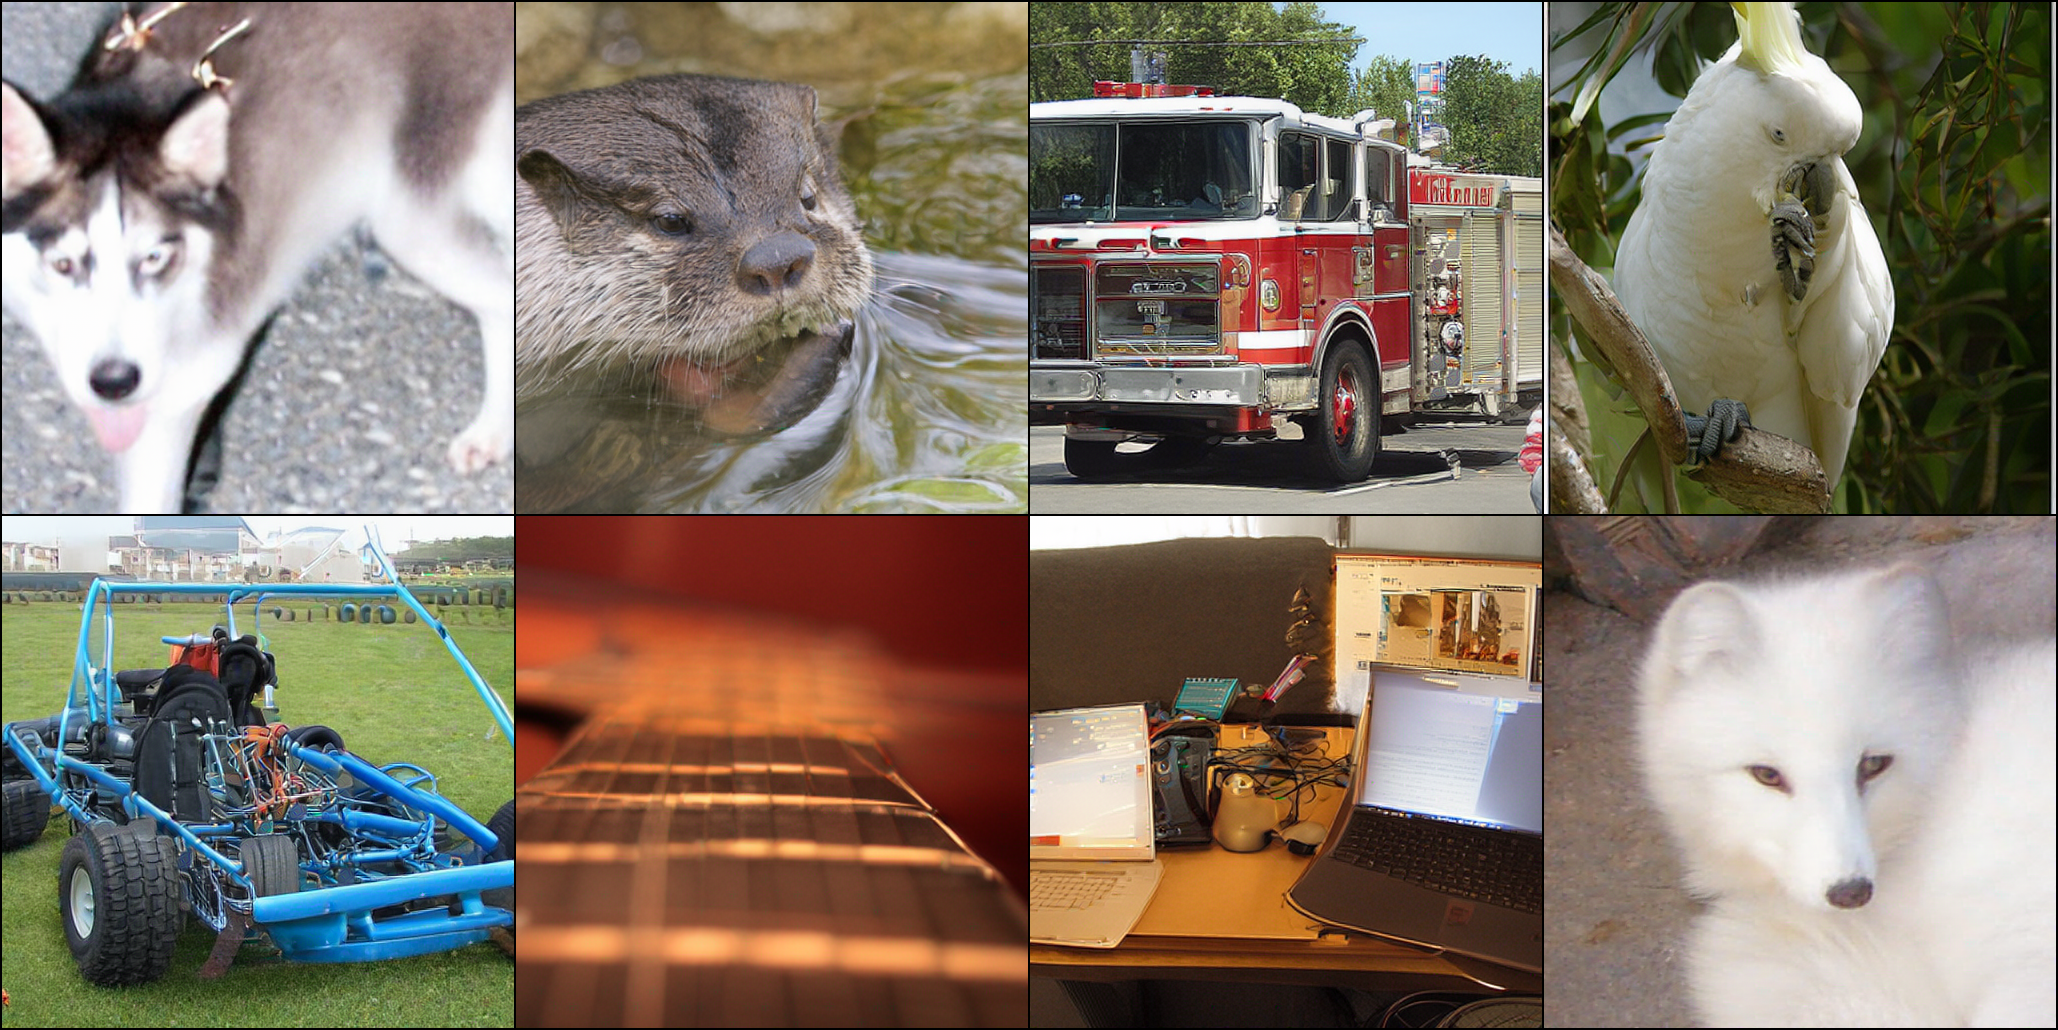

In [23]:
# Set user inputs:
seed = 1000 #@param {type:"number"}
torch.manual_seed(seed)
num_sampling_steps = 250 #@param {type:"slider", min:0, max:1000, step:1}
cfg_scale = 2.0 #@param {type:"slider", min:1, max:10, step:0.1}
class_labels = 250, 360, 555, 89, 573, 402, 620, 279 #@param {type:"raw"}
samples_per_row = 4 #@param {type:"number"}
mode = "sde" #@param ["ODE", "SDE"]
path_type = 'linear'
guidance_low = 0.0 #@param {type:"slider", min:0.0, max:0.5, step:0.05}
guidance_high = 0.8 #@param {type:"slider", min:0.5, max:1.0, step:0.05}
using_cfg = cfg_scale > 1.0

# Create sampling noise:
n = len(class_labels)
z = torch.randn(n, ae.num_latent_tokens, ae.codebook_embed_dim, device=device)
y = torch.tensor(class_labels, device=device)

# Setup classifier-free guidance:
z = torch.cat([z, z], 0)
y_null = torch.tensor([1000] * n, device=device)
y = torch.cat([y, y_null], 0)
model_kwargs = dict(y=y, cfg_scale=cfg_scale)

# Sample images:
sampling_kwargs = dict(
    model=sit, 
    latents=z,
    y=y,
    num_steps=num_sampling_steps, 
    cfg_scale=cfg_scale,
    guidance_low=guidance_low,
    guidance_high=guidance_high,
    path_type=path_type,
)
with torch.no_grad() and torch.cuda.amp.autocast():
    if mode == "sde":
        samples = euler_maruyama_sampler(**sampling_kwargs).to(torch.float32)
    elif mode == "ode":
        samples = euler_sampler(**sampling_kwargs).to(torch.float32)
    else:
        raise NotImplementedError()
    
    if using_cfg:
        samples, _ = samples.chunk(2, dim=0)  # Remove null class samples

    samples = ae.decode(samples * ae.vq_std + ae.vq_mean)
    
samples = torch.clamp(samples, -1.0, 1.0)
samples = (samples + 1) / 2
print(samples.shape)


# Save and display images:
save_image(samples, "sample_512.png", nrow=int(samples_per_row), 
           normalize=True, value_range=(0.0, 1.0))
samples = Image.open("sample_512.png")
display(samples)